In [1]:
source("/home/user/data2/lit/bin/lit_utils.R")
source("/home/user/data3/lit/project/sORFs/sORFs.utils.R")
lib_text()
lib_plot()
library(colorspace)

In [2]:
ancestors_path <- "../processed/check_denovo/merged/merged_ancestors"
spec_out_path <- "../processed/check_denovo/merged/merged_spec.out"
times_in_genome_trans_path <- "../processed/blastp_check/times_in_genome_trans.txt"
outgroup_homolog.peptide_similarity_path <- "../processed/blastp_check/outgroup_homolog.peptide_similarity.txt"

In [3]:
map_path <- "../processed/work_mafsInRegion/safe_map_merged.tsv"

In [4]:
fread_c(ancestors_path) -> ancestor
fread_c(spec_out_path) -> spec.out
read.table(times_in_genome_trans_path) -> times_in_genome_trans
colnames(times_in_genome_trans) <- c("orf_id","loc_times_blat","gene_times_blastn","gene_times_blastn_pc")
fread_c(outgroup_homolog.peptide_similarity_path) -> outgroup_homolog.peptide_similarity
read.table(map_path) -> map

In [5]:
head(ancestor,1)
head(spec.out,1)
head(times_in_genome_trans,1)
head(outgroup_homolog.peptide_similarity,1)
head(map)

,orf_id,sp,ev_age,syn_age,gained,gained_convergent,lost,denovo,seq
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
1,PB.4512.20__chr10__4__4202__58__121__uORF__ATG,hg38,placentalia,placentalia,0,0,2,0,MPPRAPASAPAPGSSAPART


,orf_id,lineage,farthest species,pident,evalue,qcovs
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,PB.4512.20:chr10:+|4|4202:58:121|uORF|ATG,simiiformes,PB.4512.20:chr10:+|4|4202:58:121|uORF|ATG_PB.4512.20:chr10:+|4|4202:58:121|uORF|ATG_calJac3_1.000000_0,100,5.21e-10,100


,orf_id,loc_times_blat,gene_times_blastn,gene_times_blastn_pc
,<chr>,<int>,<int>,<int>
1,PB.27846.7:chr20:+|33|2948:350:527|uORF|ATG,1,1,1


,Gene ID,Outgroup Homolog
,<chr>,<chr>
1,PB.27846.7:chr20:+|33|2948:350:527|uORF|ATG,human


,V1,V2
,<chr>,<chr>
1,PB.28982.11__chr22__-__58__3646__605__737__noncoding__TTG,PB.28982.11:chr22:-|58|3646:605:737|noncoding|TTG
2,PB.28983.12__chr22__31__2738__336__480__noncoding__ATG,PB.28983.12:chr22:+|31|2738:336:480|noncoding|ATG
3,PB.28985.15__chr22__-__21__2181__220__337__noncoding__ATG,PB.28985.15:chr22:-|21|2181:220:337|noncoding|ATG
4,PB.28985.1__chr22__-__102__2589__1148__1256__noncoding__CTG,PB.28985.1:chr22:-|102|2589:1148:1256|noncoding|CTG
5,PB.28985.28__chr22__-__9__3089__113__269__noncoding__CTG,PB.28985.28:chr22:-|9|3089:113:269|noncoding|CTG
6,PB.28985.3__chr22__-__155__1796__1603__1756__dORF__ATG,PB.28985.3:chr22:-|155|1796:1603:1756|dORF|ATG


In [6]:
merge(ancestor,map,by.x="orf_id",by.y="V1") %>% mutate(orf_id=NULL) %>% mutate(orf_id=V2) -> ancestor_1

In [7]:
table(ancestor_1$ev_age)
table(ancestor_1$syn_age)
table(spec.out$lineage)
table(outgroup_homolog.peptide_similarity$`Outgroup Homolog`)


   boreoeutheria       catarrhini euarchontoglires         hominoid 
            1547              643             1543              756 
           human           mammal      placentalia         primates 
             727             3306             3248             1134 
   primatomorpha      simiiformes 
             436              585 


   boreoeutheria       catarrhini euarchontoglires         hominoid 
             420              118              155               47 
          mammal      placentalia         primates    primatomorpha 
            7284             5520              160               36 
     simiiformes 
             185 


   boreoeutheria       catarrhini euarchontoglires         hominoid 
            1215             2816              327             2170 
           human           mammal      placentalia         primates 
            1622              961             1880              362 
   primatomorpha      simiiformes 
              93             2395 


   boreoeutheria       catarrhini euarchontoglires         hominoid 
             176               61               96               31 
           human           mammal      placentalia         primates 
           12493             1267              176               16 
     simiiformes 
             205 

In [8]:
nrow(ancestor_1)
nrow(spec.out)
nrow(times_in_genome_trans)
nrow(outgroup_homolog.peptide_similarity)

[1] 13925

[1] 13841

[1] 14521

[1] 14521

In [9]:
# 读入newly detected SEP list
# fread("./output/sep_add_basic_ms_ribo_info_group_retained.txt") -> all_sep
# ancestor$orf_id <- sub(ancestor$orf_id,pattern = "__",replacement = ":")
# spec.out$orf_id <- sub(spec.out$orf_id,pattern = "__",replacement = ":")
merge(ancestor_1[,c("orf_id","ev_age","syn_age","denovo")],spec.out[,c("orf_id","lineage")],all.y=T) -> m_evo
m_evo$denovo[is.na(m_evo$denovo)] <- 1
m_evo$ev_age[is.na(m_evo$ev_age)] <- "human"
m_evo$syn_age[is.na(m_evo$syn_age)] <- "human"
# merge(m_evo,all_sep,by.x="orf_id",by.y="ORF_id_trans") -> all_sep_m_evo
# fwrite_c(all_sep_m_evo,"./output/S8/all_sep_m_evo.txt")

merge(m_evo,times_in_genome_trans,by="orf_id") %>% 
  merge(outgroup_homolog.peptide_similarity,by.x = "orf_id",by.y="Gene ID") -> all_sep_m_evo_add_homolog

filter(all_sep_m_evo_add_homolog,denovo==1) -> all_sep_m_evo_add_homolog_denovo

all_sep_m_evo_add_homolog_denovo %>% filter(loc_times_blat<=1 & gene_times_blastn<=1 & gene_times_blastn_pc<=1) -> res_filter_paralog

LEVELS <- c("human","hominoid","catarrhini","simiiformes","primates","primatomorpha","boreoeutheria",
            "placentalia","mammal")
res_filter_paralog$lineage <- factor(res_filter_paralog$lineage,levels=LEVELS)
res_filter_paralog$`Outgroup Homolog` <- factor(res_filter_paralog$`Outgroup Homolog`,levels=LEVELS)
res_filter_paralog$lineage_n <- as.numeric(res_filter_paralog$lineage)
res_filter_paralog$`Outgroup Homolog n` <- as.numeric(res_filter_paralog$`Outgroup Homolog`)
res_filter_paralog %>% filter(lineage_n>=`Outgroup Homolog n`) -> res_filter_paralog_ortholog

In [10]:
head(m_evo)
head(res_filter_paralog_ortholog)

,orf_id,ev_age,syn_age,denovo,lineage
,<chr>,<chr>,<chr>,<dbl>,<chr>
1,PB.1000.1:chr1:+|33|1855:374:440|iORF|CTG,placentalia,mammal,1,placentalia
2,PB.1001.3:chr1:-|9|2745:169:253|iORF|ACG,mammal,mammal,1,placentalia
3,PB.1001.41:chr1:-|217|3689:2936:2990|noncoding|GTG,catarrhini,placentalia,1,catarrhini
4,PB.10020.13:chr12:+|22|1011:465:531|noncoding|ATG,placentalia,placentalia,0,boreoeutheria
5,PB.10022.2:chr12:+|99|3182:1589:1652|dORF|ATG,primates,mammal,1,catarrhini
6,PB.10023.4:chr12:+|128|3001:2235:2307|dORF|ATG,placentalia,mammal,1,boreoeutheria


,orf_id,ev_age,syn_age,denovo,lineage,loc_times_blat,gene_times_blastn,gene_times_blastn_pc,Outgroup Homolog,lineage_n,Outgroup Homolog n
,<chr>,<chr>,<chr>,<dbl>,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<dbl>
1,PB.1001.3:chr1:-|9|2745:169:253|iORF|ACG,mammal,mammal,1,placentalia,1,1,1,human,8,1
2,PB.1001.41:chr1:-|217|3689:2936:2990|noncoding|GTG,catarrhini,placentalia,1,catarrhini,1,1,0,human,3,1
3,PB.10023.4:chr12:+|128|3001:2235:2307|dORF|ATG,placentalia,mammal,1,boreoeutheria,1,1,1,human,7,1
4,PB.10023.4:chr12:+|138|3001:2439:2562|dORF|ATG,boreoeutheria,mammal,1,simiiformes,1,1,1,human,4,1
5,PB.10023.4:chr12:+|162|3001:2895:2952|dORF|CTG,placentalia,mammal,1,primates,1,1,1,human,5,1
6,PB.10045.82:chr12:-|1|2253:2:86|uORF|ATG,human,human,1,human,1,0,0,human,1,1


In [11]:
get_p <- function(df){
  "lineage" -> col
  data <- data.frame(table(df[,col]))
  colnames(data) <- c(col,"Freq")
  data$lineage <- factor(data$lineage,levels=LEVELS)
  p <- ggplot(data,aes_string(x = col, y = "Freq",fill=col)) + 
    geom_bar(stat = "identity",width = 0.8) +
#     scale_y_continuous(expand = c(0, 0),limits=c(0,100)) +
    theme_3(rotate=T)+
    guides(fill = "none")
  p <- p+
    geom_text(aes(label = Freq), 
              position = position_dodge(0.8), # 确保标签对齐柱子
              vjust = -0.3,                  # 根据需要调整位置
              size = 5, color = "black")+
    coord_cartesian(clip = "off")
  p+scale_fill_discrete_divergingx() -> p
  return(p)
}

In [12]:
nrow(m_evo)
merge(m_evo,times_in_genome_trans,by="orf_id") %>% nrow()

[1] 13841

[1] 13841

[1] 13841

[1] 10266

[1] 8233

[1] 7638

[1] 5617

[1] 2219

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”


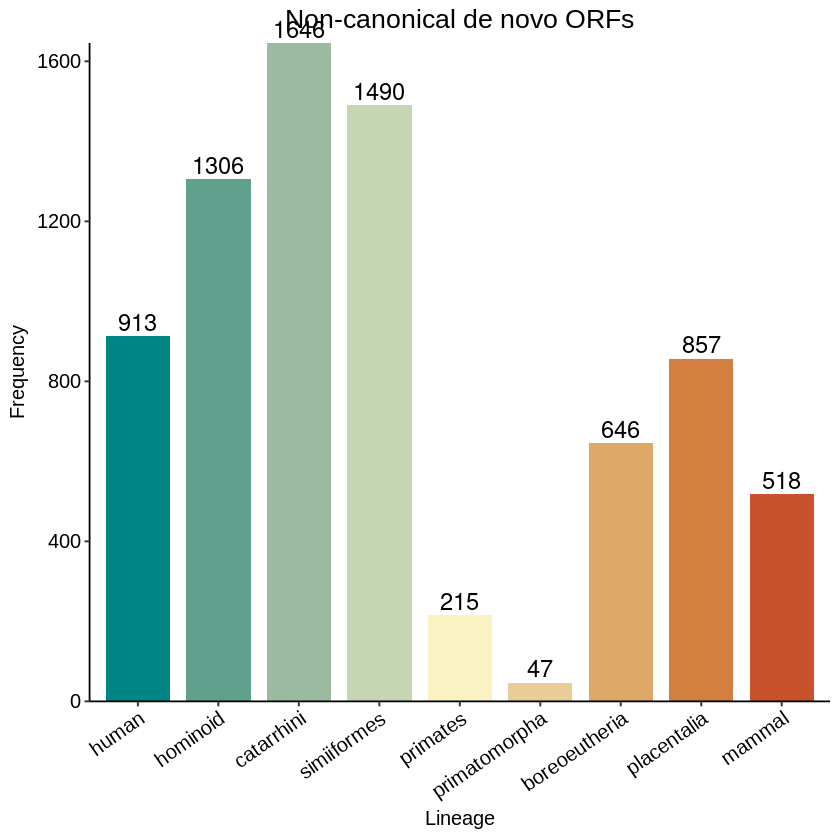

In [13]:
##### plot #####
##### basic number #####
nrow(all_sep_m_evo_add_homolog)
nrow(all_sep_m_evo_add_homolog_denovo)
nrow(res_filter_paralog)
nrow(res_filter_paralog_ortholog)
res_filter_paralog_ortholog %>% filter(lineage %in% c("human","hominoid","catarrhini","simiiformes","primates","primatomorpha")) %>% nrow()
res_filter_paralog_ortholog %>% filter(lineage %in% c("human","hominoid")) %>% nrow()
##### hominoid-specific genes #####
res_filter_paralog_ortholog %>% filter(lineage %in% c("human","hominoid")) -> denovo_genes
# table(denovo_genes$ORF_type_3) %>% sort()
# table(denovo_genes$Scodon) %>% sort()
res_filter_paralog_ortholog -> df 
get_p(df) + labs(x="Lineage",y="Frequency",title="Non-canonical de novo ORFs") + theme(plot.title=element_text(hjust=0.5,size=16))+
scale_y_continuous(expand = c(0, 0)) -> p
p
output_path <- "../figures/"
ggsave(p,filename = o("non_canonical_de_novo_orfs.pdf"),height = 5,width = 5)

In [18]:
fwrite_c(res_filter_paralog_ortholog,"../results/res_filter_paralog_ortholog.txt")
fwrite_c(all_sep_m_evo_add_homolog,"../results/all_sep_m_evo_add_homolog.txt")

In [17]:
colnames(res_filter_paralog_ortholog)
filter(all_sep_m_evo_add_homolog_denovo,orf_id=="PB.11229.2:chr12:+|26|1894:339:507|noncoding|ATG")

[1] "orf_id"               "ev_age"               "syn_age"             
 [4] "denovo"               "lineage"              "loc_times_blat"      
 [7] "gene_times_blastn"    "gene_times_blastn_pc" "Outgroup Homolog"    
[10] "lineage_n"            "Outgroup Homolog n"

orf_id,ev_age,syn_age,denovo,lineage,loc_times_blat,gene_times_blastn,gene_times_blastn_pc,Outgroup Homolog
<chr>,<chr>,<chr>,<dbl>,<chr>,<int>,<int>,<int>,<chr>
PB.11229.2:chr12:+|26|1894:339:507|noncoding|ATG,hominoid,placentalia,1,hominoid,1,2,0,human
